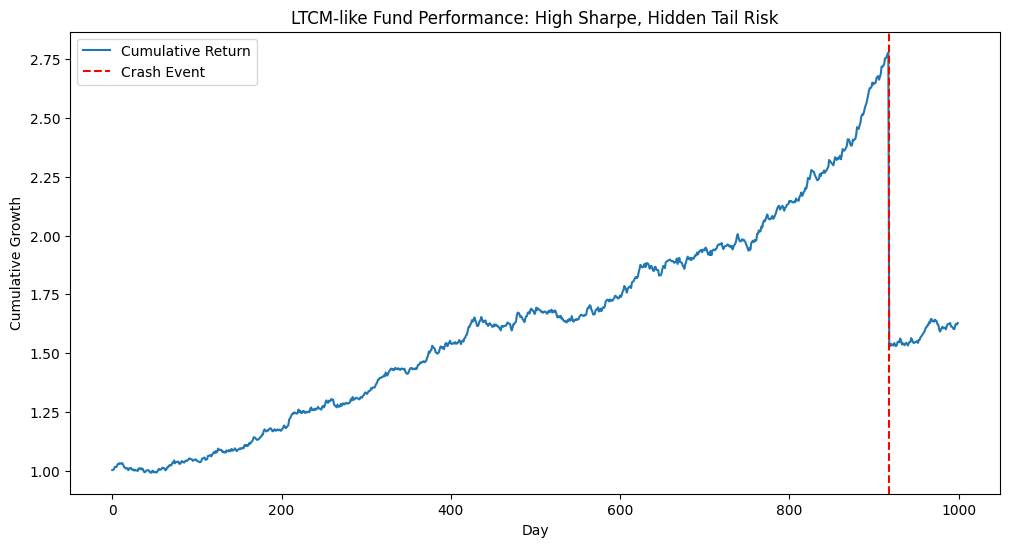

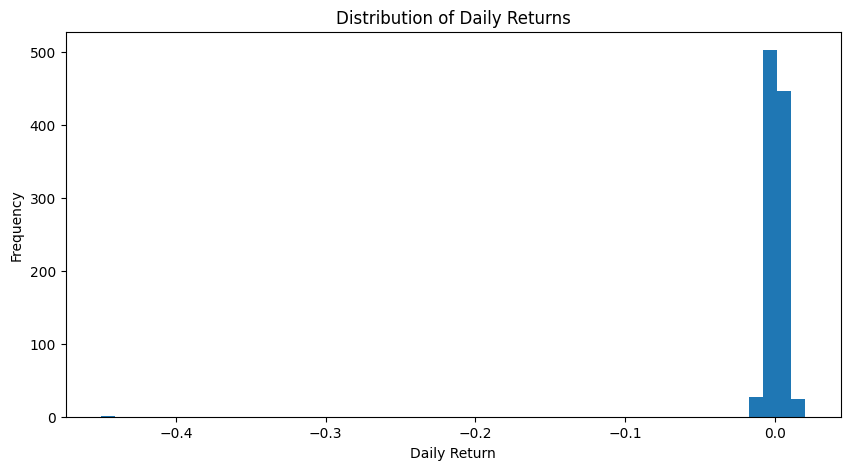

Crash occurred on day: 918
Sharpe Ratio before crash: 3.65
Sharpe Ratio after crash: 0.68


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
np.random.seed(42)
n_days = 1000
mu_daily = 0.001     # 0.1% daily return (~25% annualized)
sigma_daily = 0.005  # 0.5% daily volatility (~8% annualized)

# Generate stable daily returns
returns = np.random.normal(mu_daily, sigma_daily, n_days)

# Introduce one catastrophic event 
crash_day = np.random.randint(800, n_days)  # crash after day 800
returns[crash_day] = -0.45  # -45% tail event

# Create a DataFrame
df = pd.DataFrame(returns, columns=['Return'])
df['Cumulative'] = (1 + df['Return']).cumprod()

# Function to compute Sharpe ratio (annualized)
def sharpe_ratio(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

# Compute before/after crash
sharpe_before = sharpe_ratio(df['Return'][:crash_day])
sharpe_after = sharpe_ratio(df['Return'])

# Cumulative growth 
plt.figure(figsize=(12, 6))
plt.plot(df['Cumulative'], label='Cumulative Return')
plt.axvline(crash_day, color='red', linestyle='--', label='Crash Event')
plt.title("LTCM-like Fund Performance: High Sharpe, Hidden Tail Risk")
plt.xlabel("Day")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.show()

# Daily Returns Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['Return'], bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

# Sharpe Ratios 
print(f"Crash occurred on day: {crash_day}")
print(f"Sharpe Ratio before crash: {sharpe_before:.2f}")
print(f"Sharpe Ratio after crash: {sharpe_after:.2f}")
